# Human-in-the-Loop (HITL) in LangGraph

The agents in the earlier notebooks run from start to finish on their own. That is risky when a tool does something real, like sending an email, deleting a record, or making a payment. **Human-in-the-loop** lets the graph **pause**, show a person what it is about to do, and **resume** only after that person approves, edits, or rejects it.

HITL builds on the memory from `03_AI_Agents_with_Memory`. The graph needs a **checkpointer** so it can save its state at the pause and pick up from the same spot later.

## Core building blocks

| Concept | What it is | In code |
|---|---|---|
| **`interrupt()`** | Pauses the graph inside a node and sends a value to the human | `decision = interrupt({"question": "Approve?"})` |
| **`Command(resume=...)`** | Resumes the paused graph; the value becomes the return value of `interrupt()` | `graph.invoke(Command(resume="yes"), config=config)` |
| **Checkpointer + thread** | Saves the paused state so the run can continue later | `builder.compile(checkpointer=InMemorySaver())` and a `thread_id` |
| **`__interrupt__`** | Key in the result that shows the graph is paused and what it is asking | `result["__interrupt__"]` |

## How it works

```
invoke(inputs, config)              ──▶ run nodes ──▶ interrupt() ──▶ save checkpoint, return __interrupt__
human reviews and decides
invoke(Command(resume=...), config) ──▶ re-run paused node, interrupt() returns the decision ──▶ continue
```

> **Note:** on resume, the paused node runs again **from the beginning**, not from the `interrupt()` line. Keep code before `interrupt()` free of side effects (or make it safe to repeat).

## Common patterns

- **Approve / reject:** stop before a sensitive tool call and only run it if the human says yes.
- **Edit state:** let the human fix the LLM's output or tool arguments before continuing.
- **Ask for input:** pause to collect missing information from the user.

Imports: `from langgraph.types import interrupt, Command`

In [1]:
import os
from dotenv import load_dotenv

# Change working directory to the parent folder
os.chdir(os.path.abspath(".."))
load_dotenv()

True

In [2]:
## got too many 429 so switching to open ai/gemini models
# from langchain.chat_models import init_chat_model
# llm = init_chat_model("groq:qwen/qwen3.8-27b")
# llm

In [3]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-5-mini")
llm

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.2', 'langchain-openai': '1.6.2'}}, profile={'name': 'GPT-5 Mini', 'release_date': '2025-08-07', 'last_updated': '2025-08-07', 'open_weights': False, 'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True, 'reasoning_effort_levels': ['minimal', 'low', 'medium', 'high']}, client=<openai.resources.chat.completions.completions.Completions object at 0x111839550>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x111839fd0>, root_

In [4]:
## Import 

from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt
print("Import Successfull")

Import Successfull


In [5]:
class State(TypedDict):
    messages:Annotated[list, add_messages]

@tool
def human_assistance(query:str) -> str:
    """Escalate the user's request to a human expert.

    Call this right away whenever the user asks for human help, expert guidance,
    or asks you to request assistance for them. Don't ask follow-up questions
    first; summarize what the user needs in `query`.
    """
    human_response = interrupt({"query":query}) # interrupt workflow to get human approval/feedback
    return human_response['data']

tool = TavilySearch(max_results=3)
tools = [tool, human_assistance]
llm_wiht_tools = llm.bind_tools(tools)
llm_wiht_tools


_ChatModelBinding(bound=ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.2', 'langchain-openai': '1.6.2'}}, profile={'name': 'GPT-5 Mini', 'release_date': '2025-08-07', 'last_updated': '2025-08-07', 'open_weights': False, 'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True, 'reasoning_effort_levels': ['minimal', 'low', 'medium', 'high']}, client=<openai.resources.chat.completions.completions.Completions object at 0x111839550>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions objec

In [6]:
# chatbot 
def chatbot(state: State):
    """ LLm chatbot wit toolcall"""
    message = llm_wiht_tools.invoke(state["messages"])
    # human in the look will interrupt the tool executing
    # will disable parallel tool calling to avoid repeating any tool invocations when we resume
    return {"messages":[message]}

## Build  graph
graph_builder = StateGraph(State)

graph_builder.add_node("chatbot",chatbot)
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools",tool_node)
graph_builder.add_conditional_edges("chatbot", tools_condition,)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")


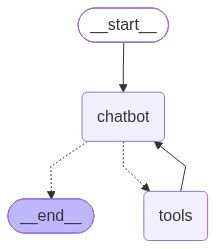

In [7]:
## Compile graph
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)
graph

In [9]:
## User input

user_input = "I need some human assistance for building an AI agent. could you request assistance for me?"
config = {"configurable":{"thread_id":"3"}}

events = graph.stream({"messages":user_input}, config=config, stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some human assistance for building an AI agent. could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (call_dZsYbZA8cssWIOkIuy5lKz1z)
 Call ID: call_dZsYbZA8cssWIOkIuy5lKz1z
  Args:
    query: User requests human assistance to build an AI agent. Summary of needs: The user said: 'I need some human assistance for building an AI agent. could you request assistance for me?' They likely need hands-on expert help with design and implementation. Ask an expert (AI engineer/systems architect/ML engineer) to contact the user and offer guidance in these areas: 1) Project scoping: clarify use case, goals, success metrics, target users, environment, and required capabilities (e.g., conversational agent, task automation, retrieval-augmented generation, autonomous agent). 2) Architecture & tech stack: recommend agent ar

In [10]:
## Human response

human_response = ("we, the experts are here to help!, we would recommend you to check out Langgraph to build your agent,",
                  "It's much more reliable and extensible then simple autonomous agents.")

human_command = Command(resume={"data":human_response})
events = graph.stream(human_command, config=config, stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (call_dZsYbZA8cssWIOkIuy5lKz1z)
 Call ID: call_dZsYbZA8cssWIOkIuy5lKz1z
  Args:
    query: User requests human assistance to build an AI agent. Summary of needs: The user said: 'I need some human assistance for building an AI agent. could you request assistance for me?' They likely need hands-on expert help with design and implementation. Ask an expert (AI engineer/systems architect/ML engineer) to contact the user and offer guidance in these areas: 1) Project scoping: clarify use case, goals, success metrics, target users, environment, and required capabilities (e.g., conversational agent, task automation, retrieval-augmented generation, autonomous agent). 2) Architecture & tech stack: recommend agent architecture (Llama/PaLM/Claude/OpenAI APIs, RAG, vector DBs, orchestration tools, tool use, safety layers), programming languages, frameworks, and deployment options (cloud, e

## Example 2: Invoice refund assistant (human approval over $100)

The `human_assistance` example above only pauses if the LLM *decides* to call that tool, which is why it sometimes skipped it. For a real guardrail, put the rule in code instead of leaving it to the model.

Here the `issue_refund` tool checks the amount itself:

- **$100 or less:** the refund goes through right away.
- **Over $100:** the tool calls `interrupt()` and waits for a human to approve or reject it. The LLM cannot skip this step.

The refund is only recorded *after* `interrupt()`, so re-running the tool on resume never refunds twice.

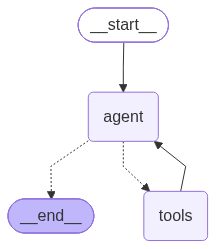

In [11]:
## Example 2: invoice refund assistant with human approval for refunds over $100

from langchain_core.messages import SystemMessage
from langchain_core.tools import tool  # re-import: `tool` was reassigned to TavilySearch above

REFUND_APPROVAL_LIMIT = 100  # USD. Refunds above this need a human

# Fake invoice "database" for the demo
INVOICES = {
    "INV-1001": {"customer": "Alice", "amount": 45.00, "status": "paid"},
    "INV-1002": {"customer": "Bob", "amount": 250.00, "status": "paid"},
    "INV-1003": {"customer": "Carol", "amount": 120.00, "status": "refunded"},
}


@tool
def get_invoice(invoice_id: str) -> dict:
    """Look up an invoice by ID (for example INV-1001). Returns the customer, amount in USD and status."""
    invoice = INVOICES.get(invoice_id.upper())
    if invoice is None:
        return {"error": f"Invoice {invoice_id} not found."}
    return {"invoice_id": invoice_id.upper(), **invoice}


@tool
def issue_refund(invoice_id: str, amount: float, reason: str) -> str:
    """Refund an invoice. Refunds over $100 are sent to a human for approval automatically."""
    invoice_id = invoice_id.upper()
    invoice = INVOICES.get(invoice_id)
    if invoice is None:
        return f"Invoice {invoice_id} not found."
    if invoice["status"] == "refunded":
        return f"Invoice {invoice_id} is already refunded."
    if amount > invoice["amount"]:
        return f"Refund of ${amount:.2f} is more than the invoice total of ${invoice['amount']:.2f}."

    # Guardrail: the approval rule lives in code, so the LLM can't skip it
    if amount > REFUND_APPROVAL_LIMIT:
        decision = interrupt({
            "question": f"Approve refund of ${amount:.2f} for {invoice_id} ({invoice['customer']})?",
            "invoice_id": invoice_id,
            "amount": amount,
            "reason": reason,
        })
        if not decision.get("approved"):
            return f"Refund for {invoice_id} was rejected by a human reviewer. Note: {decision.get('note', 'none')}"

    # The side effect happens only after approval, so re-running this tool on resume is safe
    invoice["status"] = "refunded"
    return f"Refunded ${amount:.2f} to {invoice['customer']} for {invoice_id}."


class RefundState(TypedDict):
    messages: Annotated[list, add_messages]


refund_tools = [get_invoice, issue_refund]
# One tool call per step, so resuming doesn't re-run other tool calls from the same step
refund_llm = llm.bind_tools(refund_tools, parallel_tool_calls=False)

refund_system_prompt = SystemMessage(
    "You are an invoice refund assistant. Look up the invoice with get_invoice before refunding, "
    "then use issue_refund. Only tell the user a refund was issued if issue_refund confirms it."
)


def refund_agent(state: RefundState):
    return {"messages": [refund_llm.invoke([refund_system_prompt] + state["messages"])]}


refund_builder = StateGraph(RefundState)
refund_builder.add_node("agent", refund_agent)
refund_builder.add_node("tools", ToolNode(refund_tools))
refund_builder.add_edge(START, "agent")
refund_builder.add_conditional_edges("agent", tools_condition)
refund_builder.add_edge("tools", "agent")

refund_graph = refund_builder.compile(checkpointer=MemorySaver())


def run_refund(inputs, thread_id):
    """Stream the refund graph and print any approval request it is waiting on."""
    config = {"configurable": {"thread_id": thread_id}}
    last_id = None
    for event in refund_graph.stream(inputs, config=config, stream_mode="values"):
        if "messages" in event and event["messages"][-1].id != last_id:
            last_id = event["messages"][-1].id
            event["messages"][-1].pretty_print()

    for pending in refund_graph.get_state(config).interrupts:
        print("\nPAUSED, waiting for human approval:", pending.value)


refund_graph

In [12]:
## Refund of $100 or less: no human needed

run_refund({"messages": "Please refund invoice INV-1001, the customer was charged twice."}, thread_id="refund-1")

================================ Human Message =================================

Please refund invoice INV-1001, the customer was charged twice.
================================== Ai Message ==================================
Tool Calls:
  get_invoice (call_qO1PIrJLDgEUnyX4LJLIIG2T)
 Call ID: call_qO1PIrJLDgEUnyX4LJLIIG2T
  Args:
    invoice_id: INV-1001
================================= Tool Message =================================
Name: get_invoice

{"invoice_id": "INV-1001", "customer": "Alice", "amount": 45.0, "status": "paid"}
================================== Ai Message ==================================
Tool Calls:
  issue_refund (call_j8G7IgiuaqLPuF8YWSTLTuKI)
 Call ID: call_j8G7IgiuaqLPuF8YWSTLTuKI
  Args:
    invoice_id: INV-1001
    amount: 45.0
    reason: Duplicate charge — customer was charged twice
================================= Tool Message =================================
Name: issue_refund

Refunded $45.00 to Alice for INV-1001.
================================

In [13]:
## Refund over $100: the graph pauses and waits for a human

run_refund({"messages": "Refund invoice INV-1002 in full, the product arrived damaged."}, thread_id="refund-2")

================================ Human Message =================================

Refund invoice INV-1002 in full, the product arrived damaged.
================================== Ai Message ==================================
Tool Calls:
  get_invoice (call_TwT7zUEaHPv4sK5npEwaKysB)
 Call ID: call_TwT7zUEaHPv4sK5npEwaKysB
  Args:
    invoice_id: INV-1002
================================= Tool Message =================================
Name: get_invoice

{"invoice_id": "INV-1002", "customer": "Bob", "amount": 250.0, "status": "paid"}
================================== Ai Message ==================================
Tool Calls:
  issue_refund (call_yP365anBS9nddvD24WkfJqjx)
 Call ID: call_yP365anBS9nddvD24WkfJqjx
  Args:
    invoice_id: INV-1002
    amount: 250.0
    reason: Product arrived damaged

PAUSED, waiting for human approval: {'question': 'Approve refund of $250.00 for INV-1002 (Bob)?', 'invoice_id': 'INV-1002', 'amount': 250.0, 'reason': 'Product arrived damaged'}


In [14]:
## Human decision: approve (or reject) and resume the same thread

decision = {"approved": True}
# decision = {"approved": False, "note": "Ask the customer for photos of the damage first."}

run_refund(Command(resume=decision), thread_id="refund-2")

================================== Ai Message ==================================
Tool Calls:
  issue_refund (call_yP365anBS9nddvD24WkfJqjx)
 Call ID: call_yP365anBS9nddvD24WkfJqjx
  Args:
    invoice_id: INV-1002
    amount: 250.0
    reason: Product arrived damaged
================================= Tool Message =================================
Name: issue_refund

Refunded $250.00 to Bob for INV-1002.
================================== Ai Message ==================================

Refund issued: $250.00 refunded to Bob for invoice INV-1002 (reason: Product arrived damaged).
